# 第一次作业

- 连玉君 (97020045)
- <arlionn@163.com>

## 任务说明

- 思路：
- 语言：Python 

## 存在的问题

- xxx
- xxx

=== 数据框前5行 ===
         x1        x2
0  0.166328  1.086036
1 -1.050442  3.904052
2  0.993566  1.615871
3 -1.776193 -0.414075
4  0.045428  5.135537

=== 描述性统计 ===
    count      mean       std       min       25%       50%       75%  \
x1  500.0 -0.054708  1.005530 -2.925073 -0.661887 -0.078801  0.621568   
x2  500.0  2.950268  1.511899 -1.405570  1.968980  2.915992  3.988217   

         max        偏度        峰度  
x1  3.066582 -0.075638 -0.049794  
x2  7.068702 -0.045676 -0.230831  


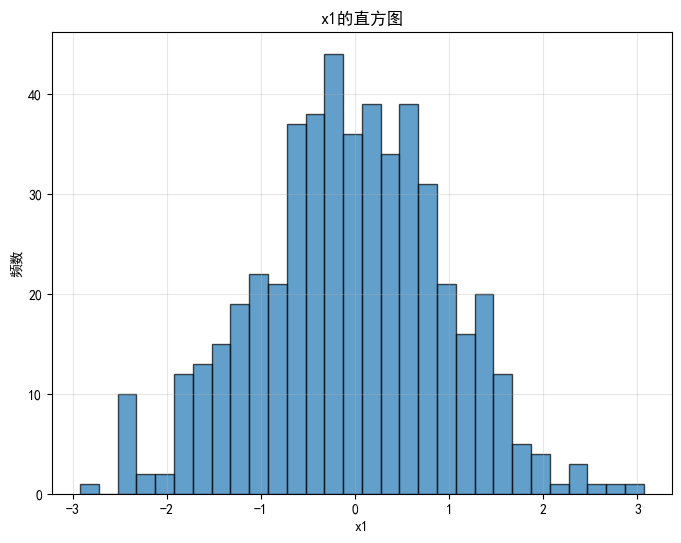

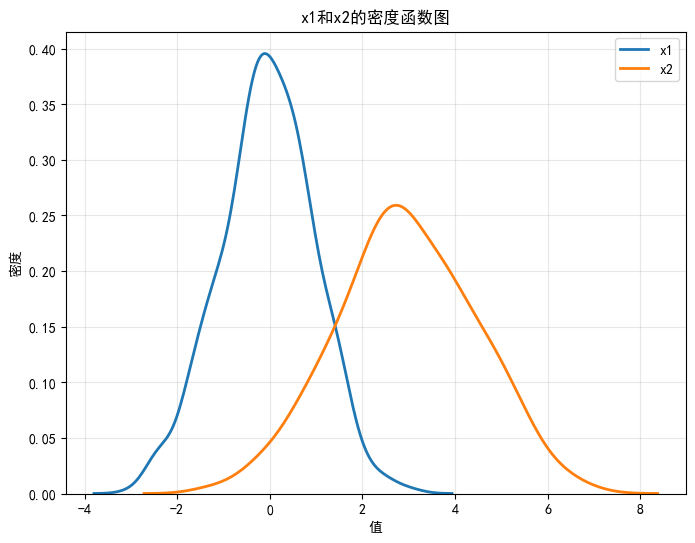

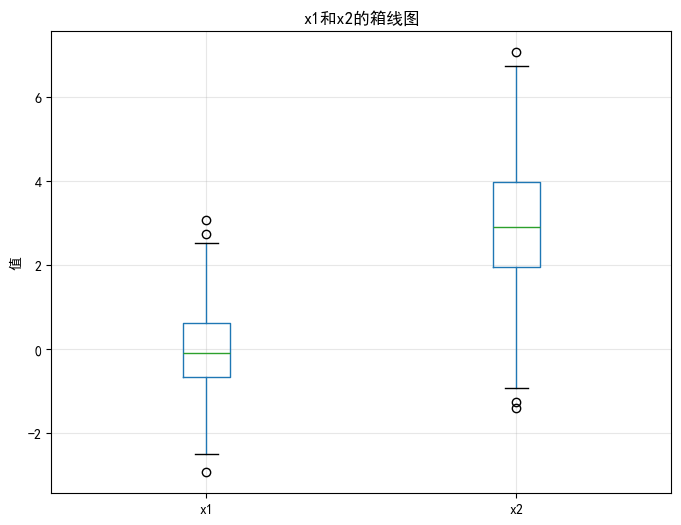

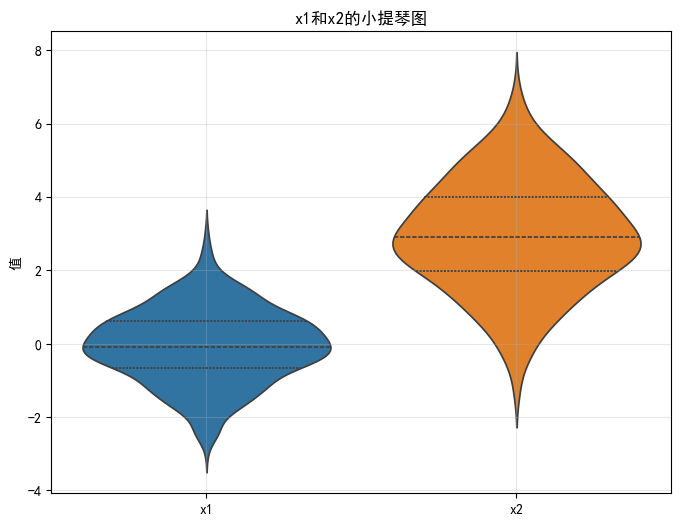


=== x1和x2的相关系数 ===
Pearson相关系数：0.4206


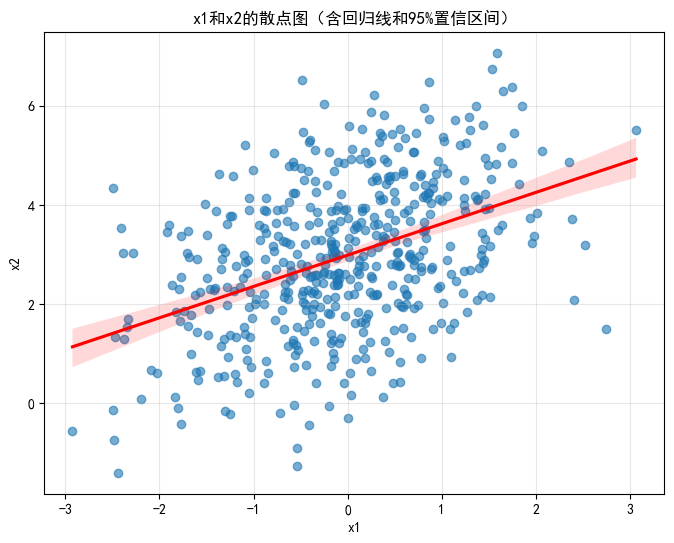

In [2]:
# 导入所需库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

# 设置中文字体（避免图表中文乱码）
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 1. 设置随机种子（替换为你的学号后三位）
seed = 123  # 此处替换为实际学号后三位
np.random.seed(seed)

# 2. 生成相关的二元正态分布数据
N = 500
# 定义均值向量和协方差矩阵
mean = [0, 3]  # x1均值0，x2均值3
# 根据相关系数计算协方差矩阵：cov(x1,x2)=corr*σ1*σ2
sigma1 = 1    # x1标准差
sigma2 = 1.5  # x2标准差
corr = 0.4    # 相关系数
cov_matrix = [
    [sigma1**2, corr * sigma1 * sigma2],
    [corr * sigma1 * sigma2, sigma2**2]
]

# 生成数据
data = np.random.multivariate_normal(mean, cov_matrix, size=N)
df = pd.DataFrame(data, columns=['x1', 'x2'])

# ========== 任务1：呈现df前5行 ==========
print("=== 数据框前5行 ===")
print(df.head())

# ========== 任务2：描述性统计（含偏度、峰度） ==========
print("\n=== 描述性统计 ===")
# 基础统计量
basic_stats = df.describe().T
# 添加偏度和峰度
basic_stats['偏度'] = [df['x1'].skew(), df['x2'].skew()]
basic_stats['峰度'] = [df['x1'].kurt(), df['x2'].kurt()]
print(basic_stats)

# ========== 任务3：x1的直方图 ==========
plt.figure(figsize=(8, 6))
plt.hist(df['x1'], bins=30, edgecolor='black', alpha=0.7)
plt.title('x1的直方图', fontsize=12)
plt.xlabel('x1', fontsize=10)
plt.ylabel('频数', fontsize=10)
plt.grid(alpha=0.3)
plt.show()

# ========== 任务4：x1和x2的密度函数图 ==========
plt.figure(figsize=(8, 6))
# 绘制密度曲线
sns.kdeplot(df['x1'], label='x1', linewidth=2)
sns.kdeplot(df['x2'], label='x2', linewidth=2)
plt.title('x1和x2的密度函数图', fontsize=12)
plt.xlabel('值', fontsize=10)
plt.ylabel('密度', fontsize=10)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ========== 任务5：x1和x2的箱线图 ==========
plt.figure(figsize=(8, 6))
df.boxplot(column=['x1', 'x2'])
plt.title('x1和x2的箱线图', fontsize=12)
plt.ylabel('值', fontsize=10)
plt.grid(alpha=0.3)
plt.show()

# ========== 任务6：x1和x2的小提琴图 ==========
plt.figure(figsize=(8, 6))
sns.violinplot(data=df[['x1', 'x2']], inner='quartile')  # inner显示四分位数
plt.title('x1和x2的小提琴图', fontsize=12)
plt.ylabel('值', fontsize=10)
plt.grid(alpha=0.3)
plt.show()

# ========== 任务7：计算x1和x2的相关系数 ==========
corr_coef = df['x1'].corr(df['x2'])
print(f"\n=== x1和x2的相关系数 ===")
print(f"Pearson相关系数：{corr_coef:.4f}")

# ========== 任务8：x1和x2的散点图（含回归线和置信区间） ==========
plt.figure(figsize=(8, 6))
sns.regplot(x='x1', y='x2', data=df, 
            scatter_kws={'alpha': 0.6},  # 散点透明度
            line_kws={'color': 'red'},    # 回归线颜色
            ci=95)  # 95%置信区间
plt.title('x1和x2的散点图（含回归线和95%置信区间）', fontsize=12)
plt.xlabel('x1', fontsize=10)
plt.ylabel('x2', fontsize=10)
plt.grid(alpha=0.3)
plt.show()